In [11]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [12]:
df= pd.read_csv('insurance.csv')

**EDA**

In [13]:
df.shape

(1338, 7)

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

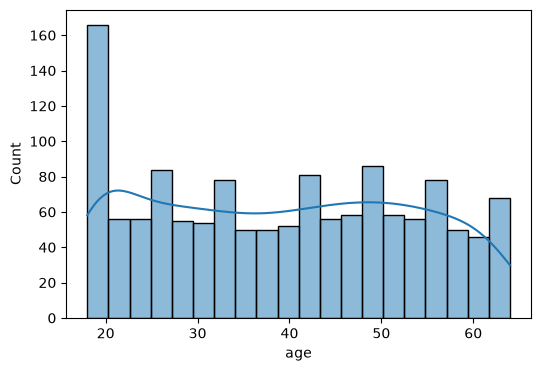

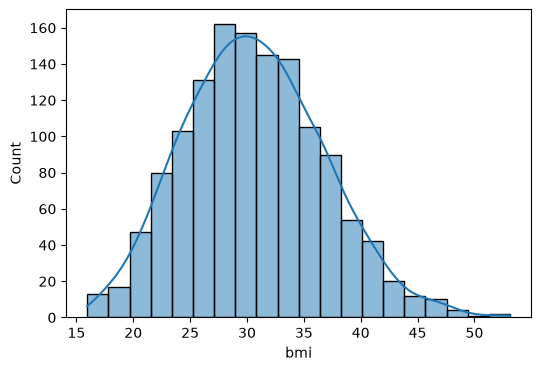

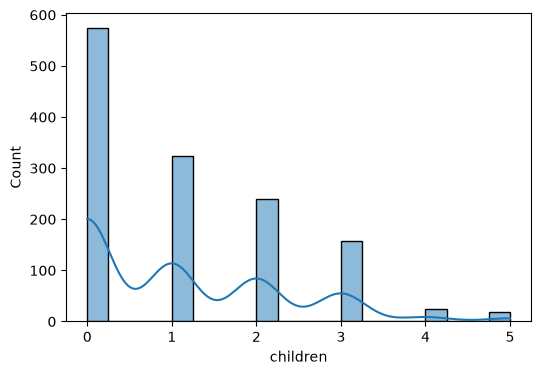

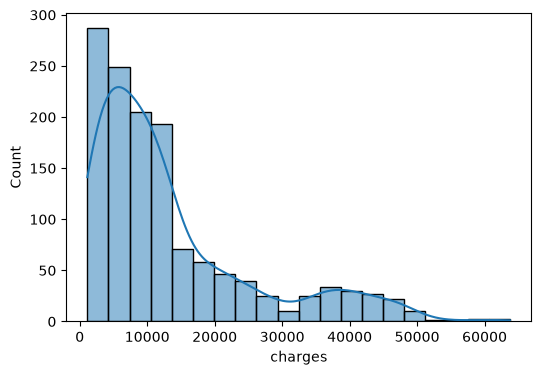

In [18]:
numeric_columns=['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='count', ylabel='region'>

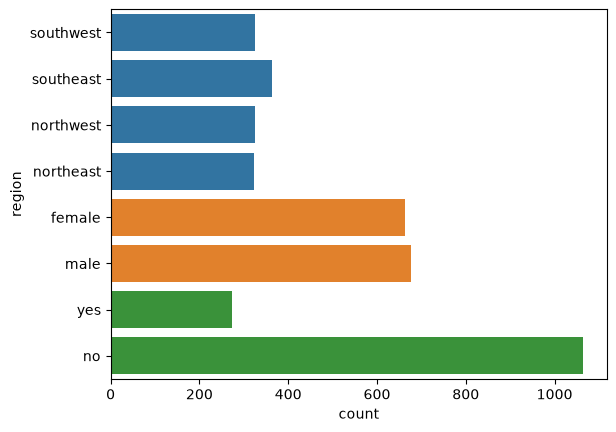

In [19]:
sns.countplot(df['region'])
sns.countplot(df['sex'])
sns.countplot(df['smoker'])

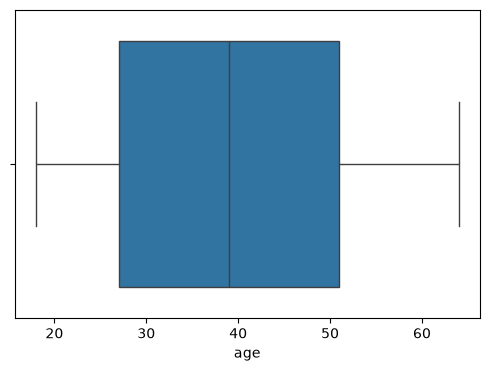

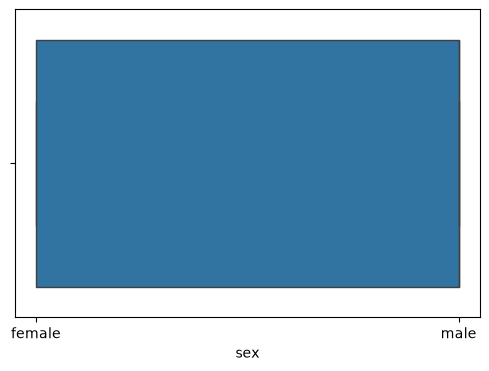

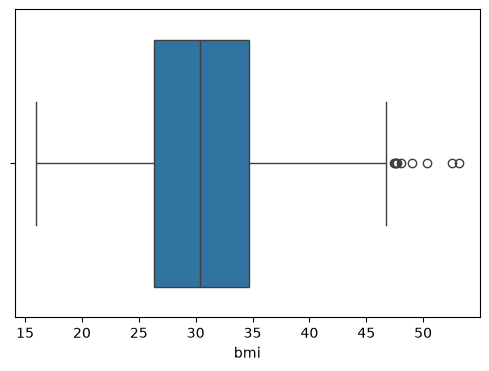

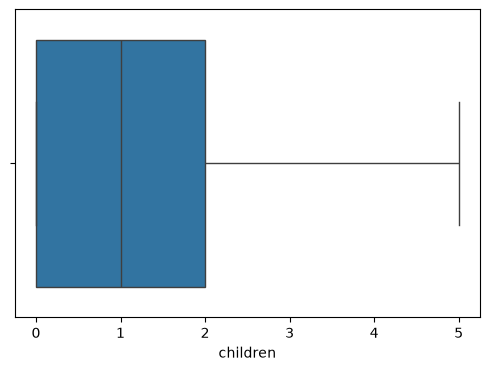

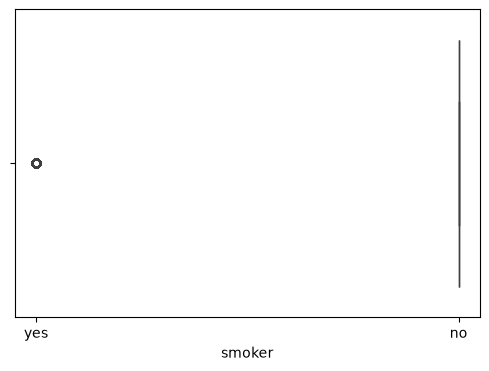

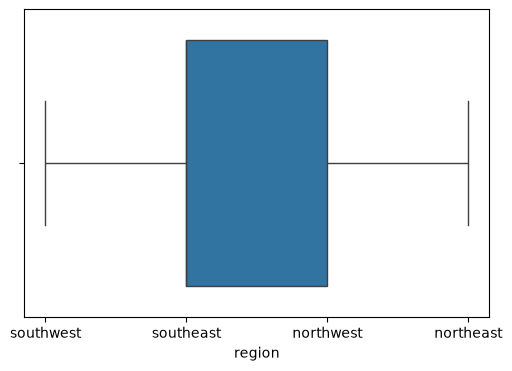

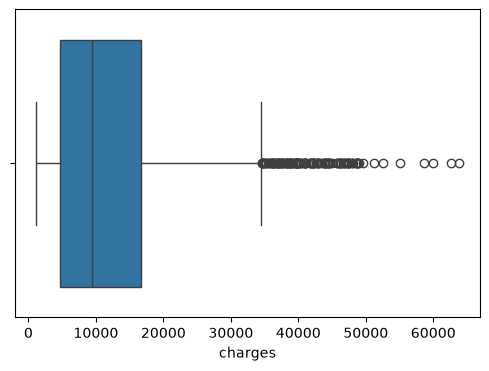

In [20]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

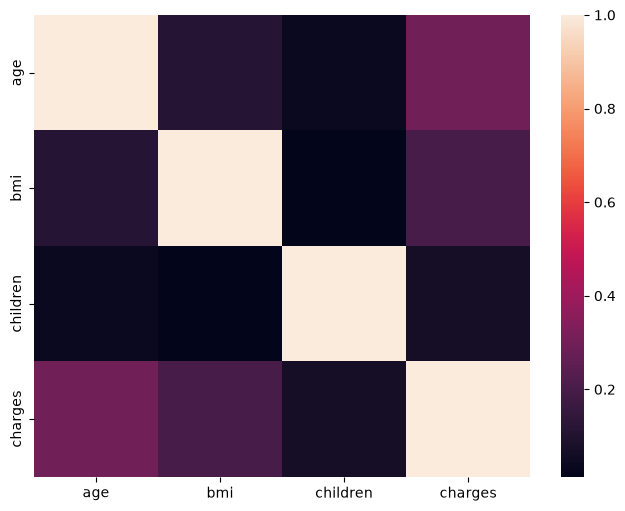

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df_cleaned.corr(numeric_only=True))

**Data Cleaning and preprocessing**

In [22]:
df_cleaned=df.copy()

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned.shape

(1338, 7)

In [26]:
df_cleaned.drop_duplicates(inplace=True)

In [27]:
df_cleaned.shape

(1337, 7)

In [28]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [29]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [30]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [31]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [32]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [33]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})

In [34]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [35]:
df_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [36]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [37]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [38]:
def is_se(text):
    return 1 if text=='southeast' else 0

In [39]:
df_cleaned['is_southeastregion']=df_cleaned['region'].apply(is_se)

In [113]:
df_cleaned['is_northeastregion'].sum()

np.int64(324)

In [41]:
def is_sw(text):
    return 1 if text=='southwest' else 0

In [42]:
df_cleaned['is_southwestregion']=df_cleaned['region'].apply(is_sw)

In [43]:
def is_nw(text):
    return 1 if text=='northwest' else 0

In [44]:
df_cleaned['is_northwestregion']=df_cleaned['region'].apply(is_nw)

In [45]:
def is_ne(text):
    return 1 if text=='northeast' else 0

In [46]:
df_cleaned['is_northeastregion']=df_cleaned['region'].apply(is_ne)

In [47]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges,is_southeastregion,is_southwestregion,is_northwestregion,is_northeastregion
0,19,1,27.900,0,1,southwest,16884.92400,0,1,0,0
1,18,0,33.770,1,0,southeast,1725.55230,1,0,0,0
2,28,0,33.000,3,0,southeast,4449.46200,1,0,0,0
3,33,0,22.705,0,0,northwest,21984.47061,0,0,1,0
4,32,0,28.880,0,0,northwest,3866.85520,0,0,1,0


In [48]:
df_cleaned.drop(columns='region',inplace=True)

<Axes: >

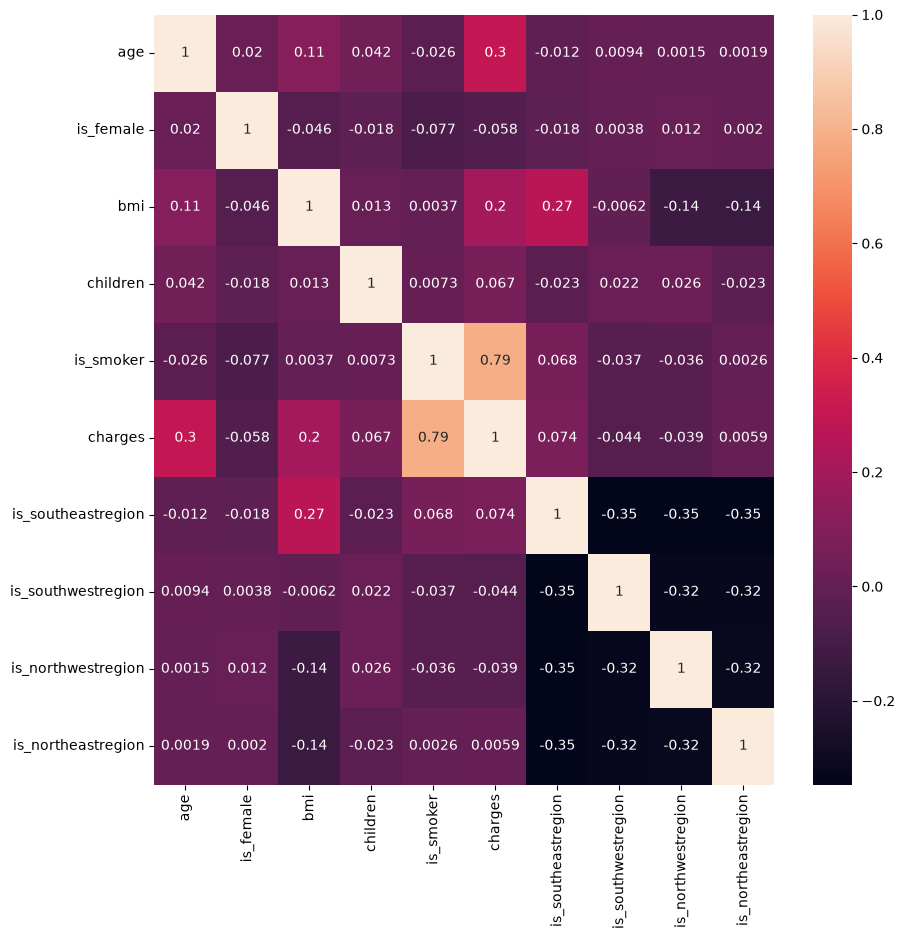

In [49]:
plt.figure(figsize=(10,10))
sns.heatmap(df_cleaned.corr(),annot=True)

# Feature Engineering and Extraction

In [50]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9, float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [51]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,is_southeastregion,is_southwestregion,is_northwestregion,is_northeastregion,bmi_category
0,19,1,27.900,0,1,16884.92400,0,1,0,0,Overweight
1,18,0,33.770,1,0,1725.55230,1,0,0,0,Obese
2,28,0,33.000,3,0,4449.46200,1,0,0,0,Obese
3,33,0,22.705,0,0,21984.47061,0,0,1,0,Normal
4,32,0,28.880,0,0,3866.85520,0,0,1,0,Overweight


In [52]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [53]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,is_southeastregion,is_southwestregion,is_northwestregion,is_northeastregion,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,1,0,0,False,True,False
1,18,0,33.770,1,0,1725.55230,1,0,0,0,False,False,True
2,28,0,33.000,3,0,4449.46200,1,0,0,0,False,False,True
3,33,0,22.705,0,0,21984.47061,0,0,1,0,True,False,False
4,32,0,28.880,0,0,3866.85520,0,0,1,0,False,True,False


In [54]:
df_cleaned=df_cleaned.astype('int')

In [55]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,is_southeastregion,is_southwestregion,is_northwestregion,is_northeastregion,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,1,0,0,0,1,0
1,18,0,33,1,0,1725,1,0,0,0,0,0,1
2,28,0,33,3,0,4449,1,0,0,0,0,0,1
3,33,0,22,0,0,21984,0,0,1,0,1,0,0
4,32,0,28,0,0,3866,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,0,1,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,1,0,0,1
1335,18,1,36,0,0,1629,1,0,0,0,0,0,1
1336,21,1,25,0,0,2007,0,1,0,0,0,1,0


# Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler
cols=['bmi','age','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [57]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,is_southeastregion,is_southwestregion,is_northwestregion,is_northeastregion,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,1,0,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,0,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,0,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,1,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0,1,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,1,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,0,0,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,1,0,0,0,1,0


# Feature Selection

In [58]:
from scipy.stats import pearsonr
selected_features=['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'is_southeastregion', 'is_southwestregion', 'is_northwestregion',
       'is_northeastregion', 'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese']
correlations = {
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features    
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
11,bmi_category_Obese,0.197660
2,bmi,0.196236
5,is_southeastregion,0.073577
3,children,0.067390
8,is_northeastregion,0.005946
7,is_northwestregion,-0.038695
6,is_southwestregion,-0.043637
1,is_female,-0.058046


In [59]:
cat_features=['is_female','is_smoker','is_southwestregion','is_southeastregion', 'is_northwestregion',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese']

In [60]:
from scipy.stats import chi2_contingency
import pandas as pd 
alpha=0.05
# converting charges into categorical value (charges ranges into bins )
df_cleaned['charges_bin']= pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_results={}
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2_stat,p_val, _,_ = chi2_contingency(contingency)
    decision = 'Reject (keep feature)' if p_val<alpha else 'Accept (drop feature)'
    chi2_results[col]={
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }
chi2_df=pd.DataFrame(chi2_results).T
chi2_df= chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject (keep feature)
is_southeastregion,15.998167,0.001135,Reject (keep feature)
is_female,10.258784,0.01649,Reject (keep feature)
bmi_category_Obese,7.654464,0.05372,Accept (drop feature)
is_southwestregion,5.091893,0.165191,Accept (drop feature)
bmi_category_Normal,4.263673,0.234364,Accept (drop feature)
bmi_category_Overweight,4.201575,0.240504,Accept (drop feature)
is_northwestregion,1.13424,0.768815,Accept (drop feature)


In [101]:
final_df=df_cleaned[['age','is_female','is_smoker','is_southeastregion','bmi','children','charges']]

In [102]:
final_df.head()

,age,is_female,is_smoker,is_southeastregion,bmi,children,charges
0,-1.440418,1,1,0,-0.517949,-0.909234,16884
1,-1.511647,0,0,1,0.462463,-0.079442,1725
2,-0.799350,0,0,1,0.462463,1.580143,4449
3,-0.443201,0,0,0,-1.334960,-0.909234,21984
4,-0.514431,0,0,0,-0.354547,-0.909234,3866


In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [106]:
from sklearn.linear_model import LinearRegression

In [107]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 3489.39, 91.67,23103.44, -478.2 , 1920.74, 645.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','is_female','is_smoker','is_southeastregion','bmi','children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8539
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [108]:
from sklearn.metrics import r2_score

In [109]:
y_pred=model.predict(X_test)

In [110]:
r2=r2_score(y_test,y_pred)
r2

0.8053741941169436

In [111]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2= 1-((1-r2)*(n-1)/(n-p-1))

In [112]:
adjusted_r2

0.8009000376598618